In [2]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for clean plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load configuration settings
CONFIG_PATH = "../configs/project_config.yaml"
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

print(f"Project Target Locale: {config['project']['locale'].upper()}")
print(f"Label Mapping: {config['data']['label_mapping']}")

Project Target Locale: US
Label Mapping: {'Exact': 3, 'Substitute': 2, 'Complement': 1, 'Irrelevant': 0}


In [3]:
EXAMPLES_PATH = "../esci-data/shopping_queries_dataset/shopping_queries_dataset_examples.parquet"

examples = pd.read_parquet(
    EXAMPLES_PATH,
    filters=[("product_locale", "=", "us")],
)
examples = examples[examples["small_version"] == 1].reset_index(drop=True)

print("shape:", examples.shape)
print()
print(examples.dtypes)
examples.head()


shape: (601354, 9)

example_id         int64
query             object
query_id           int64
product_id        object
product_locale    object
esci_label        object
small_version      int64
large_version      int64
split             object
dtype: object


,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split
0,16,!awnmower tires without rims,1,B075SCHMPY,us,I,1,1,train
1,17,!awnmower tires without rims,1,B08L3B9B9P,us,E,1,1,train
2,18,!awnmower tires without rims,1,B082K7V2GZ,us,I,1,1,train
3,19,!awnmower tires without rims,1,B07P4CF3DP,us,S,1,1,train
4,20,!awnmower tires without rims,1,B07C1WZG12,us,E,1,1,train


In [4]:
print("nulls per column:")
print(examples.isnull().sum())
print()

dup_example_id = examples["example_id"].duplicated().sum()
dup_pair = examples.duplicated(subset=["query_id", "product_id"]).sum()

print("duplicate example_id rows:", dup_example_id)
print("duplicate (query_id, product_id) pairs:", dup_pair)


nulls per column:
example_id        0
query             0
query_id          0
product_id        0
product_locale    0
esci_label        0
small_version     0
large_version     0
split             0
dtype: int64

duplicate example_id rows: 0
duplicate (query_id, product_id) pairs: 0


esci_label counts:
esci_label
E    261527
S    211191
I    101447
C     27189
Name: count, dtype: int64

esci_label proportions:
esci_label
E    0.435
S    0.351
I    0.169
C    0.045
Name: proportion, dtype: float64


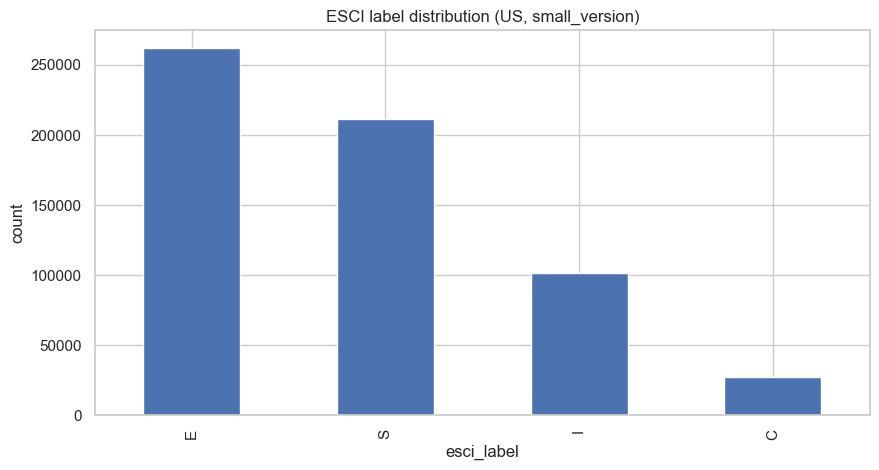

unmapped rows: 0
relevance
0    101447
1     27189
2    211191
3    261527
Name: count, dtype: int64


In [5]:
print("esci_label counts:")
print(examples["esci_label"].value_counts())
print()
print("esci_label proportions:")
print(examples["esci_label"].value_counts(normalize=True).round(3))

examples["esci_label"].value_counts().plot(kind="bar", title="ESCI label distribution (US, small_version)")
plt.ylabel("count")
plt.show()

LABEL_MAP = config["data"]["label_mapping"]  # {'Exact':3,'Substitute':2,'Complement':1,'Irrelevant':0}
FULL_TO_CODE = {"E": "Exact", "S": "Substitute", "C": "Complement", "I": "Irrelevant"}

examples["esci_label_full"] = examples["esci_label"].map(FULL_TO_CODE)
examples["relevance"] = examples["esci_label_full"].map(LABEL_MAP)

unmapped = examples["relevance"].isnull().sum()
print("unmapped rows:", unmapped)
assert unmapped == 0, "found esci_label values not in mapping"

print(examples["relevance"].value_counts().sort_index())


unique queries: 29844

judged pairs per query:
count    29844.000000
mean        20.149913
std          9.476979
min          8.000000
25%         16.000000
50%         16.000000
75%         16.000000
max        188.000000
dtype: float64


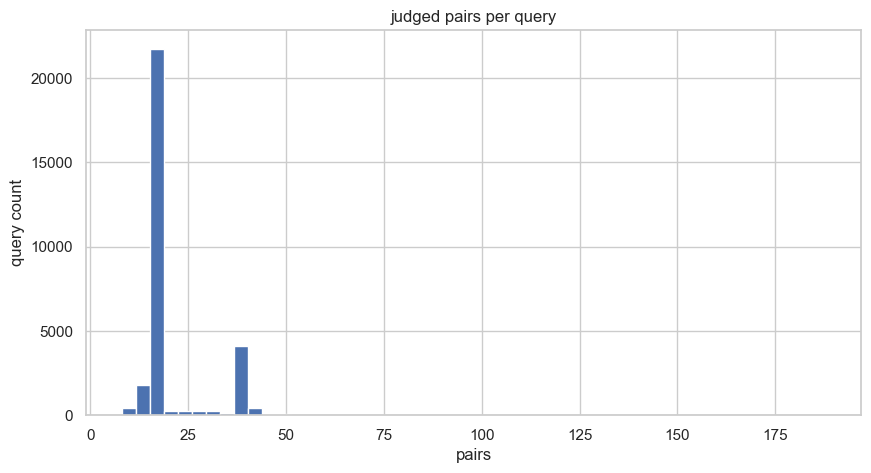


queries with <3 judged pairs: 0 (0.0%)

query token-length distribution:
count    29844.000000
mean         3.888118
std          1.827272
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         29.000000
Name: query, dtype: float64


query
1      947
2     4913
3     7894
4     7373
5     4513
6     2296
7     1032
8      454
9      204
10      82
11      44
12      16
13       9
14       3
15       1
Name: count, dtype: int64

In [6]:
n_queries = examples["query_id"].nunique()
print("unique queries:", n_queries)

pairs_per_query = examples.groupby("query_id").size()
print()
print("judged pairs per query:")
print(pairs_per_query.describe())

pairs_per_query.hist(bins=50)
plt.title("judged pairs per query")
plt.xlabel("pairs")
plt.ylabel("query count")
plt.show()

low_coverage = (pairs_per_query < 3).sum()
print()
print(f"queries with <3 judged pairs: {low_coverage} ({low_coverage/n_queries:.1%})")

query_len = examples.drop_duplicates("query_id")["query"].str.split().str.len()
print()
print("query token-length distribution:")
print(query_len.describe())
query_len.value_counts().sort_index().head(15)


In [7]:
PRODUCTS_PATH = "../esci-data/shopping_queries_dataset/shopping_queries_dataset_products.parquet"

judged_product_ids = examples["product_id"].unique()
print("unique judged product_ids:", len(judged_product_ids))

products_us = pd.read_parquet(
    PRODUCTS_PATH,
    filters=[("product_locale", "=", "us")],
)
print("products_us shape (before subset):", products_us.shape)

products = products_us[products_us["product_id"].isin(judged_product_ids)].reset_index(drop=True)
del products_us

print("products shape (judged subset):", products.shape)
print()
print(products.dtypes)
products.head()


unique judged product_ids: 482105
products_us shape (before subset): (1215854, 7)
products shape (judged subset): (482105, 7)

product_id              object
product_title           object
product_description     object
product_bullet_point    object
product_brand           object
product_color           object
product_locale          object
dtype: object


,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale
0,B0188A3QRM,"Amazon Basics Woodcased #2 Pencils, Unsharpene...",None,144 woodcase #2 HB pencils made from high-qual...,Amazon Basics,Yellow,us
1,B075VXJ9VG,"BAZIC Pencil #2 HB Pencils, Latex Free Eraser,...",<p><strong>BACK TO BAZIC</strong></p><p>Our go...,&#11088; UN-SHARPENED #2 PREMIUM PENCILS. Each...,BAZIC Products,12-count,us
2,B07G7F6JZ6,Emraw Pre Sharpened Round Primary Size No 2 Ju...,<p><b>Emraw Pre-Sharpened #2 HB Wood Pencils -...,✓ PACK OF 8 NUMBER 2 PRESHARPENED BEGINNERS PE...,Emraw,Yellow,us
3,B07MGKC3DD,"BIC Evolution Cased Pencil, #2 Lead, Gray Barr...",None,Premium #2 HB lead pencils with break-resistan...,Design House,Gray,us
4,B07NH2D2CP,Maped Essentials Triangular Graphite #2 Pencil...,None,Classic Yellow #2 Graphite Pencils with a mode...,Maped Helix USA,Yellow,us


In [8]:
print("nulls per column (judged products subset):")
print(products.isnull().sum())
print()
print("null rate:")
print((products.isnull().mean() * 100).round(1))

joined = examples.merge(products, on="product_id", how="inner")
print()
print("examples rows:", len(examples))
print("joined rows:", len(joined))
assert len(joined) == len(examples), "join dropped or duplicated rows"

joined.sample(10, random_state=42)[
    ["query", "product_title", "product_brand", "esci_label", "relevance"]
]


nulls per column (judged products subset):
product_id                   0
product_title                0
product_description     230346
product_bullet_point     63627
product_brand            27191
product_color           155144
product_locale               0
dtype: int64

null rate:
product_id               0.0
product_title            0.0
product_description     47.8
product_bullet_point    13.2
product_brand            5.6
product_color           32.2
product_locale           0.0
dtype: float64

examples rows: 601354
joined rows: 601354


,query,product_title,product_brand,esci_label,relevance
580135,woman penny loafers shoes,"Sperry Women's Seaport Penny Tri Tone Loafer, ...",Sperry,E,3
457048,retaine eye drops for dry eyes preservative free,Systane Long Lasting Lubricant Eye Drops Vials...,Systane,S,2
302081,jamie oliver veg,From Crook to Cook: Platinum Recipes from Tha ...,Chronicle Books,S,2
53986,75 inch grill cover,Classic Accessories Veranda Water-Resistant 72...,Classic Accessories,I,0
521540,tai chi,Tai Chi: Discover The Ancient Art,None,E,3
571291,wheelbarrow 4 cubic feet,"The Burro Buddy, USA Made Lawn/Garden Tray for...",The Little Burros,E,3
469249,sade poster framed,Vakseen Art - No Ordinary Love - Sade Portrait...,Vakseen Art,S,2
266113,hair goal lol,LOL Surprise L.O.L. Dolls Series 2 Wave 1 Lets...,L.O.L. Surprise!,S,2
133966,bully style running boards,APS Black OE Style Nerf Bars Running Boards Co...,APS,S,2
304690,jewelry stainless steel,1.5mm Stainless Steel Classical Plain Stackabl...,Jude Jewelers,E,3


title token length:
count    482105.000000
mean         16.740515
std           8.274565
min           1.000000
25%          10.000000
50%          15.000000
75%          23.000000
max          80.000000
Name: product_title, dtype: float64

description token length (non-null only):
count    251759.000000
mean        130.009569
std          92.734504
min           0.000000
25%          50.000000
50%         114.000000
75%         200.000000
max         728.000000
Name: product_description, dtype: float64


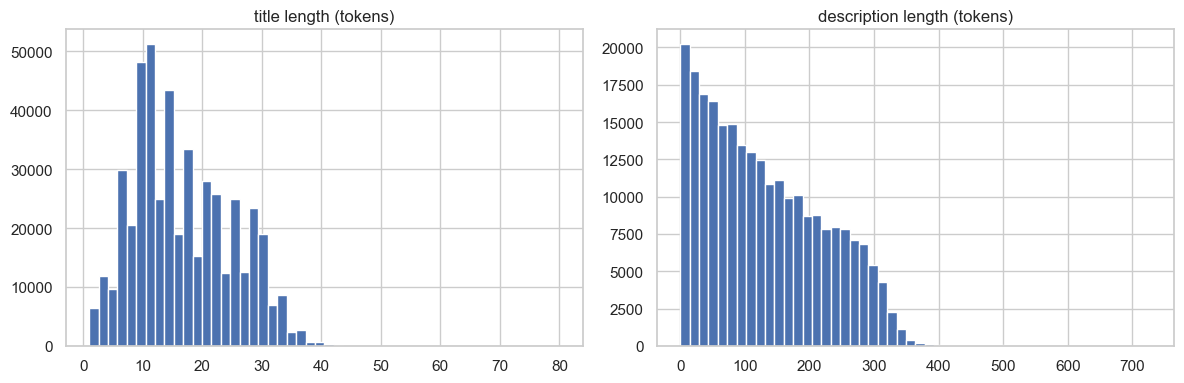

In [9]:
title_len = products["product_title"].str.split().str.len()
desc_len = products["product_description"].str.split().str.len()

print("title token length:")
print(title_len.describe())
print()
print("description token length (non-null only):")
print(desc_len.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
title_len.hist(bins=50, ax=axes[0])
axes[0].set_title("title length (tokens)")
desc_len.dropna().hist(bins=50, ax=axes[1])
axes[1].set_title("description length (tokens)")
plt.tight_layout()
plt.show()


In [10]:
from sklearn.model_selection import train_test_split

query_summary = (
    examples.groupby("query_id")
    .agg(n_pairs=("product_id", "size"), mean_relevance=("relevance", "mean"))
    .reset_index()
)

query_summary["relevance_bin"] = pd.qcut(query_summary["mean_relevance"], q=4, duplicates="drop")
print(query_summary["relevance_bin"].value_counts().sort_index())
query_summary.head()


relevance_bin
(0.0759, 1.763]    7461
(1.763, 2.188]     7751
(2.188, 2.5]       8018
(2.5, 2.975]       6614
Name: count, dtype: int64


,query_id,n_pairs,mean_relevance,relevance_bin
0,1,16,1.750000,"(0.0759, 1.763]"
1,2,38,1.026316,"(0.0759, 1.763]"
2,5,40,2.325000,"(2.188, 2.5]"
3,6,40,2.275000,"(2.188, 2.5]"
4,9,16,2.125000,"(1.763, 2.188]"


In [11]:
SEED = config["project"]["seed"]
TRAIN_FRAC = config["splits"]["train"]
VAL_FRAC = config["splits"]["val"]
TEST_FRAC = config["splits"]["test"]

train_qs, temp_qs = train_test_split(
    query_summary,
    train_size=TRAIN_FRAC,
    stratify=query_summary["relevance_bin"],
    random_state=SEED,
)

val_qs, test_qs = train_test_split(
    temp_qs,
    train_size=VAL_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp_qs["relevance_bin"],
    random_state=SEED,
)

print("train queries:", len(train_qs))
print("val queries:", len(val_qs))
print("test queries:", len(test_qs))

train_ids = set(train_qs["query_id"])
val_ids = set(val_qs["query_id"])
test_ids = set(test_qs["query_id"])

assert not (train_ids & val_ids)
assert not (train_ids & test_ids)
assert not (val_ids & test_ids)
assert len(train_ids) + len(val_ids) + len(test_ids) == len(query_summary)
print("no overlap, all queries accounted for")


train queries: 20890
val queries: 4477
test queries: 4477
no overlap, all queries accounted for


In [12]:
import os

SPLIT_DIR = "../data/processed/splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_qs[["query_id"]].to_csv(f"{SPLIT_DIR}/train_query_ids.csv", index=False)
val_qs[["query_id"]].to_csv(f"{SPLIT_DIR}/validation_query_ids.csv", index=False)
test_qs[["query_id"]].to_csv(f"{SPLIT_DIR}/test_query_ids.csv", index=False)
print("saved split files to", SPLIT_DIR)

def summarize_split(name, qids):
    sub = examples[examples["query_id"].isin(qids)]
    return {
        "split": name,
        "n_queries": len(qids),
        "n_judged_pairs": len(sub),
        "mean_pairs_per_query": round(len(sub) / len(qids), 2),
        "pct_exact": round((sub["relevance"] == 3).mean() * 100, 1),
        "pct_substitute": round((sub["relevance"] == 2).mean() * 100, 1),
        "pct_complement": round((sub["relevance"] == 1).mean() * 100, 1),
        "pct_irrelevant": round((sub["relevance"] == 0).mean() * 100, 1),
    }

summary = pd.DataFrame([
    summarize_split("train", train_ids),
    summarize_split("validation", val_ids),
    summarize_split("test", test_ids),
])
summary


saved split files to ../data/processed/splits


,split,n_queries,n_judged_pairs,mean_pairs_per_query,pct_exact,pct_substitute,pct_complement,pct_irrelevant
0,train,20890,421127,20.16,43.4,35.2,4.5,16.9
1,validation,4477,89411,19.97,43.5,35.3,4.5,16.8
2,test,4477,90816,20.29,43.7,34.8,4.8,16.7
